# Mahakoshal Refractories Pvt. Ltd.
## Python Notebook — Data Generation, EDA & Charts
**Step 1 of 2** — Run this first. It generates the dataset and all 5 charts.

---

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings("ignore")

RED       = "#C0392B"
DARK_RED  = "#922B21"
LIGHT_RED = "#FADBD8"
GREEN     = "#27AE60"
BLUE      = "#1F3864"
ORANGE    = "#E67E22"
PALETTE   = ["#C0392B","#922B21","#E74C3C","#CB4335","#A93226","#7B241C","#641E16","#4A0E0E"]

plt.rcParams["font.family"]     = "DejaVu Sans"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["figure.facecolor"] = "#FFFFFF"
plt.rcParams["axes.facecolor"]  = "#FAFAFA"
plt.rcParams["grid.alpha"]      = 0.35

print("✓ Libraries loaded successfully.")

✓ Libraries loaded successfully.


## 2. Generate Dataset (600 Orders)

In [2]:
import random
from datetime import datetime, timedelta

random.seed(42)

industries = {"Iron & Steel":0.32,"Cement":0.15,"Power":0.14,
              "Non-Ferrous":0.12,"Glass":0.08,"Petrochemical":0.08,
              "Ceramic":0.06,"Fertilizer":0.05}

regions = ["Mumbai","Delhi","Kolkata","Chennai","Pune","Ahmedabad",
           "Hyderabad","Bhopal","Raipur","Jamshedpur","Nagpur",
           "Surat","Vizag","Ranchi","Export-Africa"]

products = {
    "Shaped":[("High Alumina Brick",4200,2800),("Fireclay Brick",2800,1800),
              ("Silica Brick",3100,2000),("Magnesia Brick",5500,3600),
              ("Chrome Magnesia Brick",6200,4100),("Insulation Brick",1900,1200)],
    "Unshaped":[("Low Cement Castable",3800,2300),("Gunning Mix",2600,1500),
                ("Ramming Mass",2200,1300),("Mortar",1600,950),
                ("Plastic Refractory",2900,1750),("Refractory Coating",2100,1200)]
}

clients = {
    "Iron & Steel":["JSW Steel","Tata Steel","SAIL","Jindal Steel","RINL"],
    "Cement":["UltraTech Cement","ACC","Ambuja Cement","Shree Cement","Dalmia Cement"],
    "Power":["NTPC","NPCIL","Adani Power","Tata Power","CESC"],
    "Non-Ferrous":["BALCO","Hindalco","Vedanta","NALCO","Sterlite"],
    "Glass":["HNG Glass","Saint Gobain","Borosil","AGI Glaspac","Piramal Glass"],
    "Petrochemical":["HPCL","BPCL","IOC","ONGC","Reliance"],
    "Ceramic":["Kajaria Ceramics","Somany Ceramics","RAK Ceramics","H&R Johnson","Orient Bell"],
    "Fertilizer":["NFL","IFFCO","Chambal Fertilizers","Coromandel","Deepak Fertilizers"]
}

salespeople = ["Rajesh Kumar","Amit Sharma","Priya Singh","Vikram Patel",
               "Sunita Rao","Deepak Joshi","Neha Gupta","Sanjay Tiwari"]
sal_weights = [0.20,0.18,0.12,0.11,0.10,0.10,0.10,0.09]

records = []
order_num = 1000

for _ in range(600):
    industry     = random.choices(list(industries.keys()), weights=list(industries.values()))[0]
    product_type = random.choice(["Shaped","Unshaped"])
    prod_name, unit_price, unit_cost = random.choice(products[product_type])
    region      = random.choice(regions)
    client      = random.choice(clients[industry])
    salesperson = random.choices(salespeople, weights=sal_weights)[0]

    order_date = datetime(2023,1,1) + timedelta(days=random.randint(0,729))
    qty = random.randint(5,200)
    if order_date.month in [10,11,12]:
        qty = int(qty * 1.38)

    revenue = qty * unit_price
    cost    = qty * unit_cost
    profit  = revenue - cost
    margin  = round((profit / revenue)*100, 2)

    promised = random.randint(14,30)
    if region == "Export-Africa":
        delay = random.randint(10,45)
    elif region in ["Raipur","Ranchi","Jamshedpur"]:
        delay = random.randint(-3,20)
    else:
        delay = random.randint(-5,25)
    delay  = max(0, delay)
    actual = promised + delay
    delivery_date = order_date + timedelta(days=actual)

    records.append({
        "Order_ID":          f"MRPL-{order_num}",
        "Order_Date":        order_date.strftime("%Y-%m-%d"),
        "Delivery_Date":     delivery_date.strftime("%Y-%m-%d"),
        "Industry":          industry,
        "Client_Name":       client,
        "Region":            region,
        "Salesperson":       salesperson,
        "Product_Name":      prod_name,
        "Product_Type":      product_type,
        "Quantity_MT":       qty,
        "Unit_Price_INR":    unit_price,
        "Unit_Cost_INR":     unit_cost,
        "Total_Revenue_INR": revenue,
        "Total_Cost_INR":    cost,
        "Gross_Profit_INR":  profit,
        "Gross_Margin_Pct":  margin,
        "Promised_Days":     promised,
        "Actual_Days":       actual,
        "Delay_Days":        delay,
        "On_Time_Delivery":  "Yes" if delay == 0 else "No",
        "Quarter":           f"Q{(order_date.month-1)//3+1}",
        "Month":             order_date.strftime("%b-%Y")
    })
    order_num += 1

df = pd.DataFrame(records)
print(f"✓ Dataset created: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"✓ Date range: {df['Order_Date'].min()} to {df['Order_Date'].max()}")
df.head()

✓ Dataset created: 600 rows x 22 columns
✓ Date range: 2023-01-01 to 2024-12-30


,Order_ID,Order_Date,Delivery_Date,Industry,Client_Name,Region,Salesperson,Product_Name,Product_Type,Quantity_MT,...,Total_Revenue_INR,Total_Cost_INR,Gross_Profit_INR,Gross_Margin_Pct,Promised_Days,Actual_Days,Delay_Days,On_Time_Delivery,Quarter,Month
0,MRPL-1000,2023-04-15,2023-05-14,Non-Ferrous,Hindalco,Pune,Amit Sharma,Insulation Brick,Shaped,178,...,338200,213600,124600,36.84,16,29,13,No,Q2,Apr-2023
1,MRPL-1001,2023-01-28,2023-03-06,Cement,ACC,Chennai,Vikram Patel,High Alumina Brick,Shaped,148,...,621600,414400,207200,33.33,20,37,17,No,Q1,Jan-2023
2,MRPL-1002,2023-01-07,2023-02-12,Non-Ferrous,Sterlite,Bhopal,Amit Sharma,Gunning Mix,Unshaped,199,...,517400,298500,218900,42.31,19,36,17,No,Q1,Jan-2023
3,MRPL-1003,2024-01-25,2024-03-12,Cement,Ambuja Cement,Chennai,Rajesh Kumar,Gunning Mix,Unshaped,29,...,75400,43500,31900,42.31,25,47,22,No,Q1,Jan-2024
4,MRPL-1004,2024-01-23,2024-03-07,Cement,Shree Cement,Surat,Vikram Patel,Low Cement Castable,Unshaped,25,...,95000,57500,37500,39.47,23,44,21,No,Q1,Jan-2024


## 3. Data Types & Missing Values Check

In [3]:
print("DATA TYPES:")
print(df.dtypes)
print("\nMISSING VALUES:")
print(df.isnull().sum())
print("\nAll columns have zero missing values:", df.isnull().sum().sum() == 0)

DATA TYPES:
Order_ID                 str
Order_Date               str
Delivery_Date            str
Industry                 str
Client_Name              str
Region                   str
Salesperson              str
Product_Name             str
Product_Type             str
Quantity_MT            int64
Unit_Price_INR         int64
Unit_Cost_INR          int64
Total_Revenue_INR      int64
Total_Cost_INR         int64
Gross_Profit_INR       int64
Gross_Margin_Pct     float64
Promised_Days          int64
Actual_Days            int64
Delay_Days             int64
On_Time_Delivery         str
Quarter                  str
Month                    str
dtype: object

MISSING VALUES:
Order_ID             0
Order_Date           0
Delivery_Date        0
Industry             0
Client_Name          0
Region               0
Salesperson          0
Product_Name         0
Product_Type         0
Quantity_MT          0
Unit_Price_INR       0
Unit_Cost_INR        0
Total_Revenue_INR    0
Total_Cost_INR      

## 4. Executive KPI Summary

In [4]:
print("=" * 60)
print("  MAHAKOSHAL REFRACTORIES — KPI SUMMARY")
print("=" * 60)
print(f"  Total Orders     : {len(df)}")
print(f"  Total Revenue    : Rs.{df['Total_Revenue_INR'].sum()/1e7:.2f} Crore")
print(f"  Total Profit     : Rs.{df['Gross_Profit_INR'].sum()/1e7:.2f} Crore")
print(f"  Overall Margin   : {df['Gross_Profit_INR'].sum()/df['Total_Revenue_INR'].sum()*100:.1f}%")
print(f"  On-Time Delivery : {(df['On_Time_Delivery']=='Yes').sum()/len(df)*100:.1f}%")
print(f"  Total Clients    : {df['Client_Name'].nunique()}")
print(f"  Regions Served   : {df['Region'].nunique()}")
print("=" * 60)

  MAHAKOSHAL REFRACTORIES — KPI SUMMARY
  Total Orders     : 600
  Total Revenue    : Rs.21.48 Crore
  Total Profit     : Rs.8.00 Crore
  Overall Margin   : 37.3%
  On-Time Delivery : 16.3%
  Total Clients    : 40
  Regions Served   : 15


## 5. Save Dataset as CSV
> This CSV file will be imported into MySQL Workbench in the next step.

In [5]:
df.to_csv("MRPL_Sales_Data.csv", index=False)
print("✓ MRPL_Sales_Data.csv saved successfully")
print("✓ Location: same folder as this notebook")
print("✓ Rows:", len(df))
print("\nNEXT STEP: Open MySQL Workbench and import this CSV file")

✓ MRPL_Sales_Data.csv saved successfully
✓ Location: same folder as this notebook
✓ Rows: 600

NEXT STEP: Open MySQL Workbench and import this CSV file


## 6. Chart 1 — Revenue by Industry

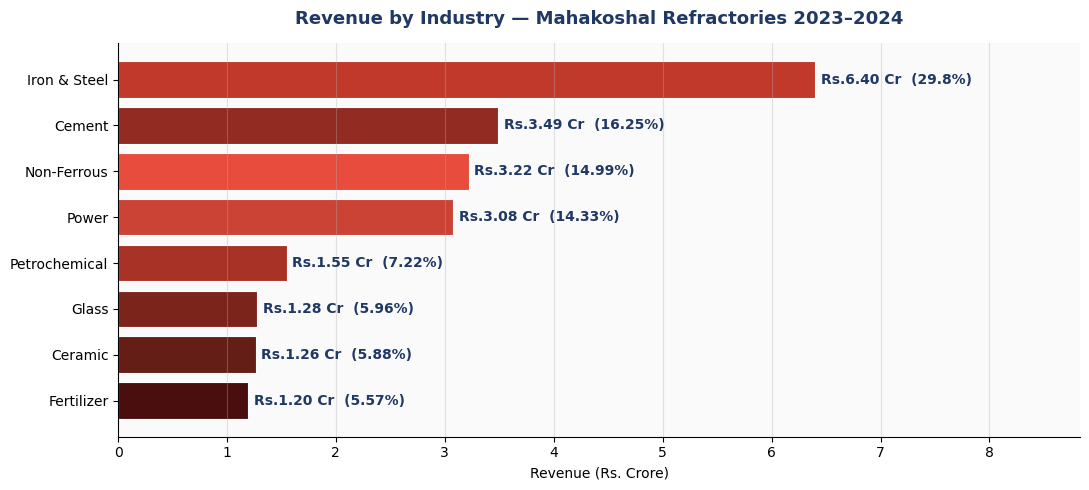

Key Finding: Iron & Steel = 29.8% of total revenue


In [6]:
fig, ax = plt.subplots(figsize=(11, 5))

ind_rev = df.groupby("Industry")["Total_Revenue_INR"].sum().sort_values(ascending=False) / 1e7
ind_pct = (ind_rev / ind_rev.sum() * 100).round(2)

bars = ax.barh(ind_rev.index, ind_rev.values,
               color=PALETTE[:len(ind_rev)], edgecolor="white", linewidth=0.8)

for bar, val, pct in zip(bars, ind_rev.values, ind_pct.values):
    ax.text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2,
            f"Rs.{val:.2f} Cr  ({pct}%)", va="center",
            fontsize=10, fontweight="bold", color=BLUE)

ax.set_title("Revenue by Industry — Mahakoshal Refractories 2023–2024",
             fontsize=13, fontweight="bold", color=BLUE, pad=14)
ax.set_xlabel("Revenue (Rs. Crore)", fontsize=10)
ax.set_xlim(0, ind_rev.max()*1.38)
ax.invert_yaxis()
ax.grid(axis="x")
plt.tight_layout()
plt.savefig("chart1_revenue_by_industry.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Key Finding: {ind_rev.idxmax()} = {ind_pct.max():.1f}% of total revenue")

## 7. Chart 2 — Delivery Delay Rate by Region

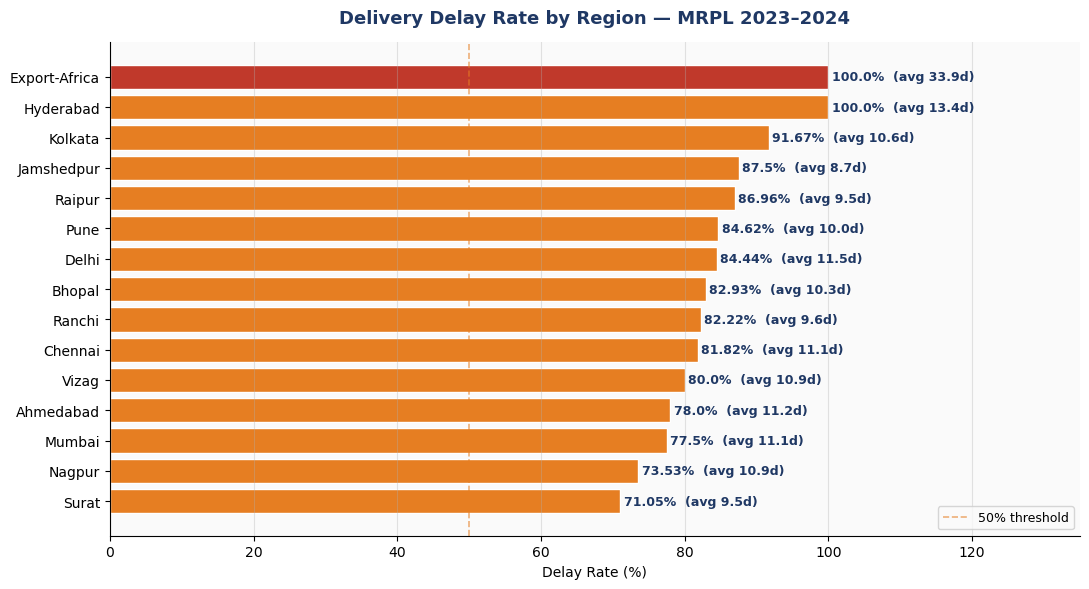

Worst: Export-Africa — 100.0% delay rate


In [7]:
delay_df = df.groupby("Region").agg(
    Total_Orders=("Order_ID","count"),
    Delayed=("Delay_Days", lambda x:(x>0).sum()),
    Avg_Delay=("Delay_Days","mean")
).reset_index()
delay_df["Delay_Rate_Pct"] = (delay_df["Delayed"]/delay_df["Total_Orders"]*100).round(2)
delay_df = delay_df.sort_values("Delay_Rate_Pct", ascending=False)

fig, ax = plt.subplots(figsize=(11, 6))
colors = [RED if r=="Export-Africa" else ORANGE if v>60 else GREEN if v<35 else ORANGE
          for r,v in zip(delay_df["Region"], delay_df["Delay_Rate_Pct"])]

bars = ax.barh(delay_df["Region"], delay_df["Delay_Rate_Pct"],
               color=colors, edgecolor="white")
for bar, val, days in zip(bars, delay_df["Delay_Rate_Pct"], delay_df["Avg_Delay"]):
    ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
            f"{val}%  (avg {days:.1f}d)", va="center",
            fontsize=9, fontweight="bold", color=BLUE)

ax.axvline(x=50, color=ORANGE, linestyle="--", linewidth=1.2, alpha=0.6, label="50% threshold")
ax.set_title("Delivery Delay Rate by Region — MRPL 2023–2024",
             fontsize=13, fontweight="bold", color=BLUE, pad=14)
ax.set_xlabel("Delay Rate (%)", fontsize=10)
ax.set_xlim(0, 135)
ax.invert_yaxis()
ax.grid(axis="x")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("chart2_delivery_delay.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Worst: {delay_df.iloc[0]['Region']} — {delay_df.iloc[0]['Delay_Rate_Pct']}% delay rate")

## 8. Chart 3 — Shaped vs Unshaped Profitability

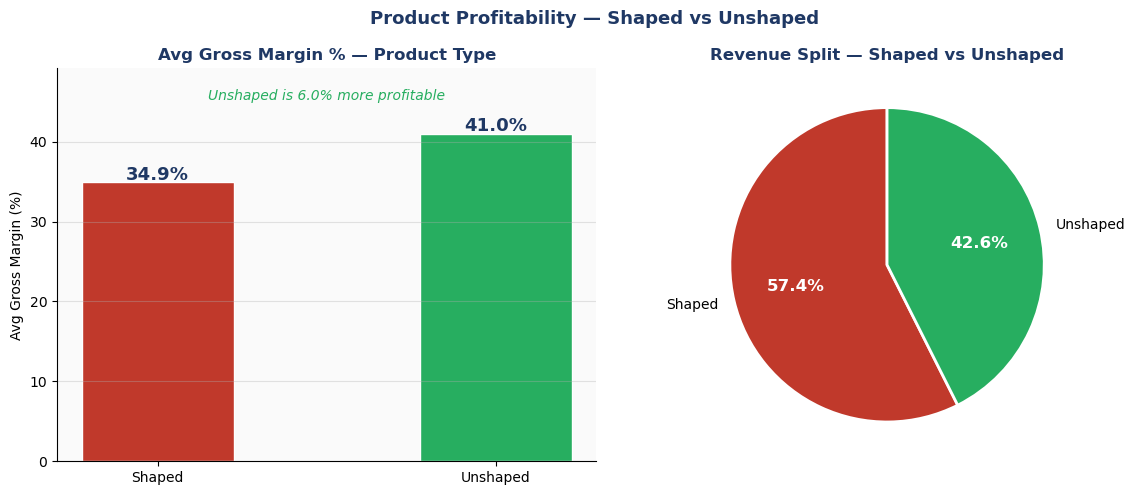

Shaped: Margin=34.9% | Revenue=Rs.12.33 Cr
Unshaped: Margin=41.0% | Revenue=Rs.9.14 Cr


In [8]:
prod_df = df.groupby("Product_Type").agg(
    Avg_Margin=("Gross_Margin_Pct","mean"),
    Revenue=("Total_Revenue_INR","sum")
).reset_index()
prod_df["Revenue_Crore"] = prod_df["Revenue"]/1e7

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
types   = prod_df["Product_Type"].tolist()
margins = prod_df["Avg_Margin"].tolist()
cols    = [GREEN if t=="Unshaped" else RED for t in types]

bars = axes[0].bar(types, margins, color=cols, edgecolor="white", width=0.45)
for bar, val in zip(bars, margins):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f"{val:.1f}%", ha="center", fontsize=13, fontweight="bold", color=BLUE)
axes[0].set_title("Avg Gross Margin % — Product Type", fontweight="bold", color=BLUE, fontsize=12)
axes[0].set_ylabel("Avg Gross Margin (%)")
axes[0].set_ylim(0, max(margins)*1.2)
axes[0].text(0.5, 0.92, f"Unshaped is {max(margins)-min(margins):.1f}% more profitable",
             ha="center", transform=axes[0].transAxes, fontsize=10, color=GREEN, style="italic")
axes[0].grid(axis="y")

wedges, texts, autotexts = axes[1].pie(
    prod_df["Revenue_Crore"], labels=types, autopct="%1.1f%%",
    colors=cols, startangle=90, wedgeprops={"edgecolor":"white","linewidth":2})
for at in autotexts:
    at.set_fontsize(12); at.set_fontweight("bold"); at.set_color("white")
axes[1].set_title("Revenue Split — Shaped vs Unshaped", fontweight="bold", color=BLUE, fontsize=12)

fig.suptitle("Product Profitability — Shaped vs Unshaped", fontsize=13, fontweight="bold", color=BLUE)
plt.tight_layout()
plt.savefig("chart3_product_profitability.png", dpi=150, bbox_inches="tight")
plt.show()
for _, r in prod_df.iterrows():
    print(f"{r['Product_Type']}: Margin={r['Avg_Margin']:.1f}% | Revenue=Rs.{r['Revenue_Crore']:.2f} Cr")

## 9. Chart 4 — Seasonal Demand by Quarter

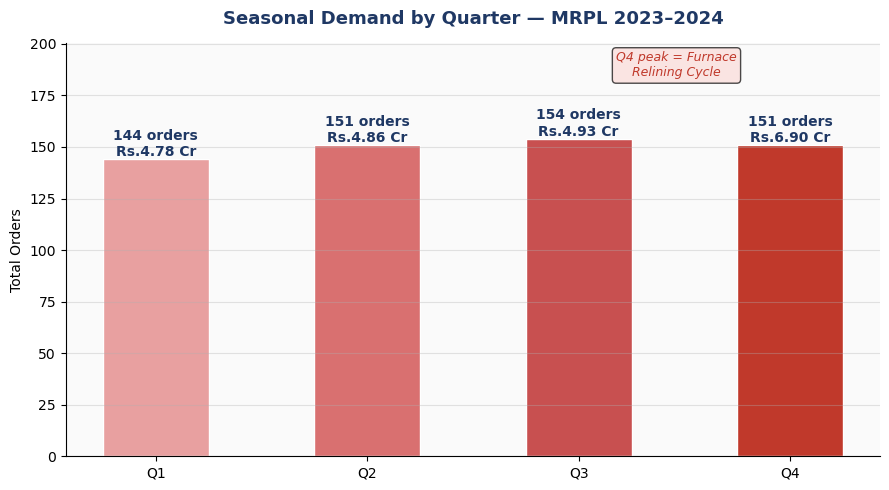

Peak Quarter: Q3 — 154 orders


In [9]:
sea_df = df.groupby("Quarter").agg(
    Total_Orders=("Order_ID","count"),
    Revenue=("Total_Revenue_INR","sum")
).reset_index()
sea_df["Revenue_Crore"] = sea_df["Revenue"]/1e7
sea_df = sea_df.sort_values("Quarter")

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = [RED if q=="Q4" else "#E8A0A0" if q=="Q1" else "#D97070" if q=="Q2" else "#C85050"
              for q in sea_df["Quarter"]]

bars = ax.bar(sea_df["Quarter"], sea_df["Total_Orders"],
              color=bar_colors, edgecolor="white", width=0.5)
for bar, orders, rev in zip(bars, sea_df["Total_Orders"], sea_df["Revenue_Crore"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.5,
            f"{orders} orders\nRs.{rev:.2f} Cr",
            ha="center", fontsize=10, fontweight="bold", color=BLUE)

ax.set_title("Seasonal Demand by Quarter — MRPL 2023–2024",
             fontsize=13, fontweight="bold", color=BLUE, pad=14)
ax.set_ylabel("Total Orders", fontsize=10)
ax.set_ylim(0, sea_df["Total_Orders"].max()*1.3)
ax.text(0.75, 0.92, "Q4 peak = Furnace\nRelining Cycle",
        ha="center", transform=ax.transAxes, fontsize=9, color=RED, style="italic",
        bbox=dict(boxstyle="round,pad=0.3", facecolor=LIGHT_RED, alpha=0.7))
ax.grid(axis="y")
plt.tight_layout()
plt.savefig("chart4_seasonal_demand.png", dpi=150, bbox_inches="tight")
plt.show()
peak = sea_df.loc[sea_df["Total_Orders"].idxmax()]
print(f"Peak Quarter: {peak['Quarter']} — {peak['Total_Orders']} orders")

## 10. Chart 5 — Salesperson Performance

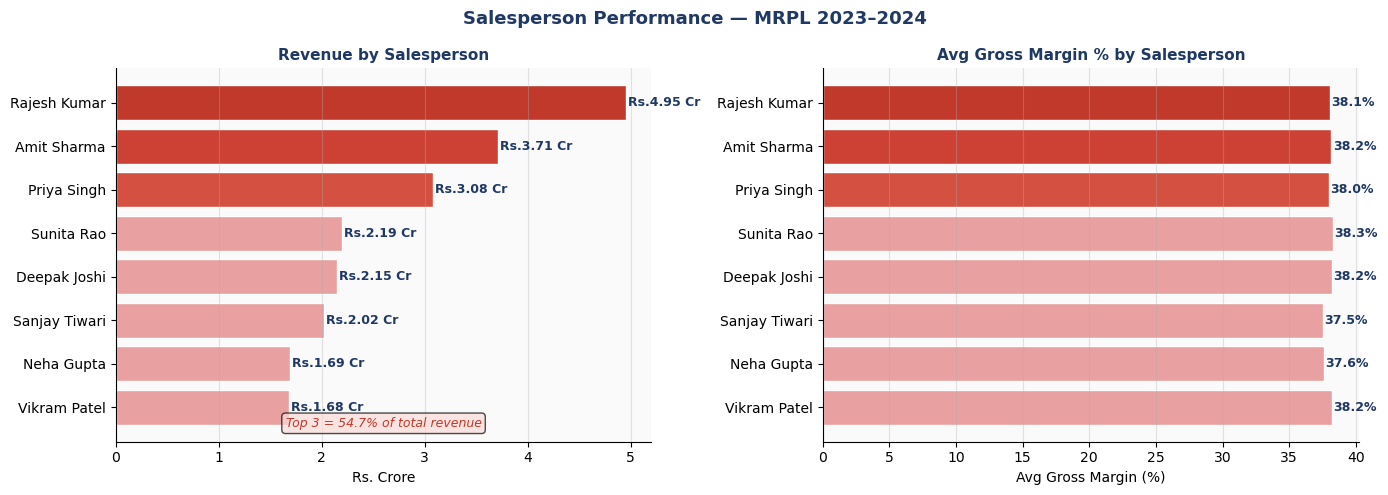

#1: Rajesh Kumar — Rs.4.95 Cr
Top 3 = 54.7% of total revenue


In [10]:
sal_df = df.groupby("Salesperson").agg(
    Total_Orders=("Order_ID","count"),
    Revenue=("Total_Revenue_INR","sum"),
    Avg_Margin=("Gross_Margin_Pct","mean"),
    OnTime=("On_Time_Delivery", lambda x:(x=="Yes").sum()/len(x)*100)
).reset_index().sort_values("Revenue", ascending=False)
sal_df["Revenue_Crore"] = sal_df["Revenue"]/1e7

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sal_colors = [RED,"#CD4135","#D45040"]+["#E8A0A0"]*(len(sal_df)-3)

bars = axes[0].barh(sal_df["Salesperson"], sal_df["Revenue_Crore"],
                    color=sal_colors, edgecolor="white")
for bar, val in zip(bars, sal_df["Revenue_Crore"]):
    axes[0].text(bar.get_width()+0.02, bar.get_y()+bar.get_height()/2,
                 f"Rs.{val:.2f} Cr", va="center", fontsize=9, fontweight="bold", color=BLUE)
axes[0].set_title("Revenue by Salesperson", fontweight="bold", color=BLUE, fontsize=11)
axes[0].set_xlabel("Rs. Crore")
axes[0].invert_yaxis()
axes[0].grid(axis="x")
top3_pct = sal_df["Revenue_Crore"].head(3).sum()/sal_df["Revenue_Crore"].sum()*100
axes[0].text(0.5, 0.04, f"Top 3 = {top3_pct:.1f}% of total revenue",
             ha="center", transform=axes[0].transAxes, fontsize=9, color=RED, style="italic",
             bbox=dict(boxstyle="round,pad=0.3", facecolor=LIGHT_RED, alpha=0.7))

axes[1].barh(sal_df["Salesperson"], sal_df["Avg_Margin"],
             color=sal_colors, edgecolor="white")
for i,(_, row) in enumerate(sal_df.iterrows()):
    axes[1].text(row["Avg_Margin"]+0.1, i, f"{row['Avg_Margin']:.1f}%",
                 va="center", fontsize=9, fontweight="bold", color=BLUE)
axes[1].set_title("Avg Gross Margin % by Salesperson", fontweight="bold", color=BLUE, fontsize=11)
axes[1].set_xlabel("Avg Gross Margin (%)")
axes[1].invert_yaxis()
axes[1].grid(axis="x")

fig.suptitle("Salesperson Performance — MRPL 2023–2024", fontsize=13, fontweight="bold", color=BLUE)
plt.tight_layout()
plt.savefig("chart5_salesperson_performance.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"#1: {sal_df.iloc[0]['Salesperson']} — Rs.{sal_df.iloc[0]['Revenue_Crore']:.2f} Cr")
print(f"Top 3 = {top3_pct:.1f}% of total revenue")

## 11. Key Findings Summary — Interview Ready

In [11]:
print("=" * 60)
print("  MAHAKOSHAL REFRACTORIES — KEY FINDINGS")
print("=" * 60)
print(f"  Total Orders   : {len(df)}")
print(f"  Total Revenue  : Rs.{df['Total_Revenue_INR'].sum()/1e7:.2f} Crore")
print(f"  Profit Margin  : {df['Gross_Profit_INR'].sum()/df['Total_Revenue_INR'].sum()*100:.1f}%")
print(f"  On-Time %      : {(df['On_Time_Delivery']=='Yes').sum()/len(df)*100:.1f}%")

top_ind = df.groupby("Industry")["Total_Revenue_INR"].sum()
print(f"\n  1. {top_ind.idxmax()} = {top_ind.max()/top_ind.sum()*100:.1f}% revenue")

delay_r = df.groupby("Region").apply(lambda x:(x["Delay_Days"]>0).sum()/len(x)*100)
print(f"  2. {delay_r.idxmax()} = {delay_r.max():.0f}% delay rate (CRITICAL)")

shaped_m   = df[df["Product_Type"]=="Shaped"]["Gross_Margin_Pct"].mean()
unshaped_m = df[df["Product_Type"]=="Unshaped"]["Gross_Margin_Pct"].mean()
print(f"  3. Unshaped {unshaped_m:.1f}% vs Shaped {shaped_m:.1f}% margin (+{unshaped_m-shaped_m:.1f}%)")

peak_q = df.groupby("Quarter")["Order_ID"].count().idxmax()
print(f"  4. {peak_q} is peak quarter — furnace relining cycle")

sal_rev = df.groupby("Salesperson")["Total_Revenue_INR"].sum()
top3_pct = sal_rev.nlargest(3).sum()/sal_rev.sum()*100
print(f"  5. Top 3 salespeople = {top3_pct:.1f}% of revenue (risk)")
print("=" * 60)
print("\n✓ 5 charts saved | MRPL_Sales_Data.csv ready for MySQL")
print("✓ Next step: Import CSV into MySQL Workbench")

  MAHAKOSHAL REFRACTORIES — KEY FINDINGS
  Total Orders   : 600
  Total Revenue  : Rs.21.48 Crore
  Profit Margin  : 37.3%
  On-Time %      : 16.3%

  1. Iron & Steel = 29.8% revenue
  2. Export-Africa = 100% delay rate (CRITICAL)
  3. Unshaped 41.0% vs Shaped 34.9% margin (+6.0%)
  4. Q3 is peak quarter — furnace relining cycle
  5. Top 3 salespeople = 54.7% of revenue (risk)

✓ 5 charts saved | MRPL_Sales_Data.csv ready for MySQL
✓ Next step: Import CSV into MySQL Workbench
